### Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

# In-context time delay embedding

### Load and plot the dependence of manifold dimension on the number of dynamical variables

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/79/zct6q7kx2yl6b1ryp2rsfbtc0000gr/T/ipykernel_71196/1069707546.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f"Manifold Dimension  $d_\mathcal{{M}}$")


Text(0, 0.5, 'Manifold Dimension  $d_\\mathcal{M}$')

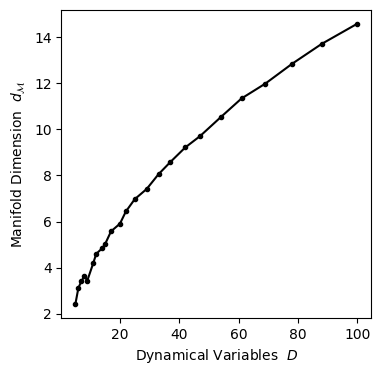

In [3]:
nvals = np.unique(np.round(np.logspace(np.log10(5), np.log10(100), 25)).astype(int))
all_gp = np.mean(np.load("./data/lorenz96_gp_log.npz", allow_pickle=True), axis=1)
all_traj = np.load("./data/lorenz96_dim_alt_log.npz", allow_pickle=True).T

plt.figure(figsize=(4, 4))
# plt.plot(nvals, all_twonn, label="TwoNN", color="k")
plt.plot(nvals, all_gp, label="GP", color="k")
plt.plot(nvals, all_gp,  '.', color="k")
# plt.legend(frameon=False)
plt.xlabel("Dynamical Variables  $D$")
plt.ylabel(f"Manifold Dimension  $d_\mathcal{{M}}$")


### Probe how properties of the transformers change with manifold dimension

In [4]:

VOCAB_SIZE = 100
N_TRAIN = 2*40_000
N_TEST = 1000
CONTEXT_LENGTH = 32*4

from icicl.models import ChronosTokenizer
tokenizer = ChronosTokenizer(VOCAB_SIZE, -3, 3)

In [ ]:
import torch
from icicl.markov import next_token_empirical_probs_custom_comb
from icicl.analysis import js_divergence as entropy
from icicl.models import load_model
from icicl.analysis import attention_rollout, erank, participation_ratio

model_path = "./data/tiny_lm.pt"

model = load_model(model_path)
all_erank = list()
all_orders = list()
for i, traj in enumerate(all_traj.T):
    print(f"i = {i}", flush=True)
    tok_train, aux = tokenizer.encode_series(traj, 100, 10)
    ## sample a random window of 6000 consecutive tokens
    start_ind = np.random.randint(0, len(tok_train) - 6000)
    train_tensor = torch.tensor(
        np.lib.stride_tricks.sliding_window_view(tok_train[:-1], CONTEXT_LENGTH),
        dtype=torch.long,
        #  device="cpu"
    )[start_ind:start_ind+6000]
    logits = model(train_tensor)
    probs = logits.softmax(dim=-1)[:, -1, :].detach().cpu().numpy()

    ## Calculate rollout rank
    attn = model(train_tensor, collect_attn=True)[1]
    A_roll = attention_rollout(attn, add_residual=False).cpu()
    all_erank.append(erank(A_roll.mean(dim=0))[1])

    ## Sweep k and find best approximating Markov chain
    combs =[np.arange(CONTEXT_LENGTH - 1, CONTEXT_LENGTH - 1 -i, -1) for i in range(1, 40)]
    combs =[np.array([CONTEXT_LENGTH - 1, CONTEXT_LENGTH - 1 -i]) for i in range(1, 40)]
    probs_markov, combs_markov = next_token_empirical_probs_custom_comb(
        tok_train[:-1], 
        train_tensor.detach().cpu().numpy(), 
        combs,
        L=VOCAB_SIZE+1, 
    )
    all_kl_div = []
    for item in probs_markov:
        kl_div = entropy(item + 1e-12, probs + 1e-12, axis=1)
        all_kl_div.append(kl_div)
    all_kl_div = np.array(all_kl_div)
    best_model_ind = np.argmin(all_kl_div, axis=0)
    # best_comb_len = np.array([len(item) for item in combs])[best_model_ind]
    best_comb_len = np.abs(np.diff(np.array(combs)[best_model_ind]))
    all_orders.append(np.mean(best_comb_len))


i = 0
i = 1
i = 2
i = 3
i = 4
i = 5
i = 6
i = 7
i = 8
i = 9
i = 10
i = 11
i = 12
i = 13
i = 14
i = 15
i = 16
i = 17


Text(0.5, 1.0, 'Correlation: 0.24')

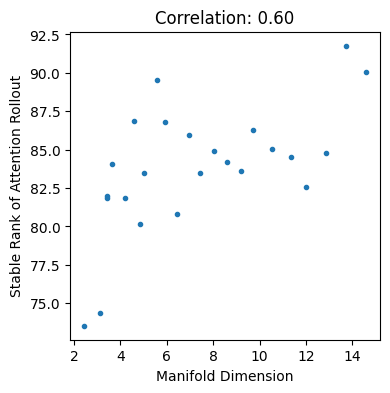

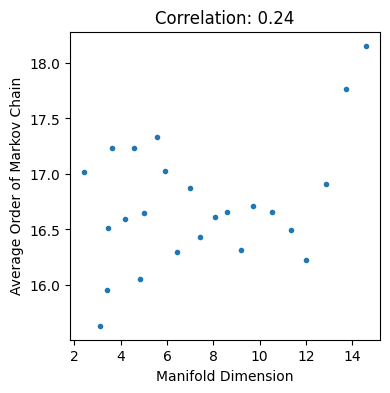

In [24]:
from scipy.stats import spearmanr

plt.figure(figsize=(4, 4))
plt.plot(all_gp, all_erank, '.')
plt.xlabel("Manifold Dimension")
plt.ylabel("Stable Rank of Attention Rollout")
plt.title(f"Correlation: {spearmanr(all_gp, all_erank)[0]:.2f}")

plt.figure(figsize=(4, 4))
plt.plot(all_gp, all_orders, '.')
plt.xlabel("Manifold Dimension")
plt.ylabel("Average Order of Markov Chain")
plt.title(f"Correlation: {spearmanr(all_gp, all_orders)[0]:.2f}")

